# Analyse van weighted attention gewichten

De `WeightedAggregate` module produceert per sample een attention-tensor met shape `(B, V)`, een attention-gewicht per camerahoek. Anders dan bij cross-attention zijn er geen leerbare query tokens. De gewichten worden berekend uit een enkele geleerde `(feat_dim x feat_dim)` projectiematrix, gevolgd door een paarsgewijze similariteit en een softmax-achtige normalisatie.

Dit notebook haalt deze gewichten uit de beste weighted-attention checkpoint op de test set en visualiseert:

1. **Attention-entropie.** Zijn de gewichten gefocust of uniform?
2. **Gemiddelde aandacht per view-positie.** Hebben bepaalde camerahoeken systematisch voorrang?
3. **Per-klasse attention heatmap.** Leunen verschillende overtredingen op verschillende views?

Dit is de tegenhanger van `attention_analysis.ipynb` (dat over cross-attention ging). Door de twee te vergelijken wordt duidelijk of de simpelere weighted-attention module meer bruikbare view-selectie heeft geleerd dan cross-attention.

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('../weighted_attention_weights.json') as f:
    entries = json.load(f)

print(f'Loaded {len(entries)} test samples')
print('Example entry:', {k: v for k, v in entries[0].items() if k != 'attention'})
print('Attention shape:', np.array(entries[0]['attention']).shape)
print('(shape (1, V) = 1 attention distribution per sample, over V views)')

Loaded 251 test samples
Example entry: {'action_id': '0', 'gt_action_class': 'Tackling', 'gt_offence': 'Offence', 'gt_severity': '1.0', 'num_views': 2, 'pred_action_idx': 0, 'pred_os_idx': 0}
Attention shape: (1, 2)
(shape (1, V) = 1 attention distribution per sample, over V views)


## Verdeling van het aantal views

Hoeveel views heeft elk testsample?

2    174
3     65
4     12
Name: count, dtype: int64


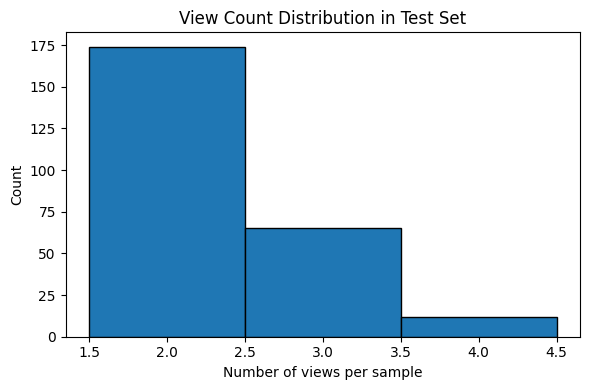

In [8]:
view_counts = [e['num_views'] for e in entries]
print(pd.Series(view_counts).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(view_counts, bins=np.arange(min(view_counts) - 0.5, max(view_counts) + 1.5), edgecolor='black')
ax.set_xlabel('Number of views per sample')
ax.set_ylabel('Count')
ax.set_title('View Count Distribution in Test Set')
plt.tight_layout()
plt.show()

## Attention-entropie

Entropie meet hoe uitgespreid de attention-verdeling is. Lage entropie (dicht bij 0) betekent dat het model zich op een view concentreert. Hoge entropie (dicht bij `log(V)`) betekent uniforme aandacht over alle views.

Een uniforme uitkomst zou betekenen dat weighted attention gelijk is aan mean pooling, precies zoals we bij cross-attention zagen.

In [9]:
def entropy(p):
    p = np.asarray(p)
    p = p[p > 1e-10]
    return -np.sum(p * np.log(p))

rows = []
for e in entries:
    attn = np.array(e['attention'])[0]  # (V,) — drop the leading num_queries=1 axis
    V = len(attn)
    max_entropy = np.log(V)
    ent = entropy(attn)
    rows.append({
        'action_id': e['action_id'],
        'action_class': e['gt_action_class'],
        'num_views': V,
        'entropy': ent,
        'entropy_ratio': ent / max_entropy if max_entropy > 0 else 0,
    })

ent_df = pd.DataFrame(rows)
print('Entropy ratio (0 = fully focused, 1 = uniform):')
print(ent_df['entropy_ratio'].describe().round(3))

Entropy ratio (0 = fully focused, 1 = uniform):
count    251.000
mean       0.854
std        0.126
min        0.417
25%        0.793
50%        0.887
75%        0.950
max        1.000
Name: entropy_ratio, dtype: float64


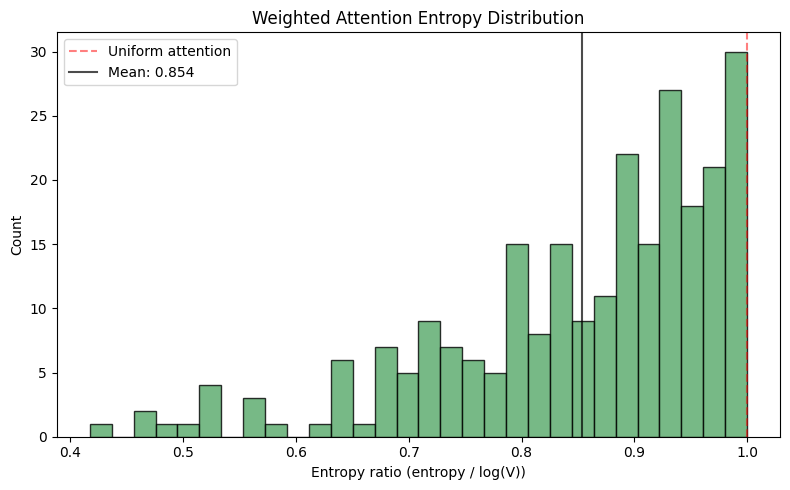

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ent_df['entropy_ratio'], bins=30, edgecolor='black', color='#55A868', alpha=0.8)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Uniform attention')
ax.axvline(x=ent_df['entropy_ratio'].mean(), color='black', linestyle='-', alpha=0.7,
           label=f"Mean: {ent_df['entropy_ratio'].mean():.3f}")
ax.set_xlabel('Entropy ratio (entropy / log(V))')
ax.set_ylabel('Count')
ax.set_title('Weighted Attention Entropy Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/plot_weighted_attention_entropy.png', dpi=150)
plt.show()

### Attention is niet-uniform maar nog wel breed

De gemiddelde entropie-ratio is 0.854, duidelijk lager dan de 0.988 die we bij cross-attention zagen. Heel weinig samples hebben scherpe aandacht (een ratio onder 0.5 is zeldzaam), maar de verdeling loopt duidelijk weg van pure uniformiteit, met een lange staart tot rond de 0.42. Weighted attention heeft voor de meeste samples geleerd af te wijken van een gelijke verdeling. Dit is het eerste concrete bewijs dat een geleerde aggregatie-module niet-triviale informatie uit de views heeft gehaald op deze dataset.

## Gemiddelde aandacht per view-positie

Beperkt tot samples met het meest voorkomende aantal views voor een eerlijke vergelijking.

Analyzing samples with exactly V=2 views (174 samples)


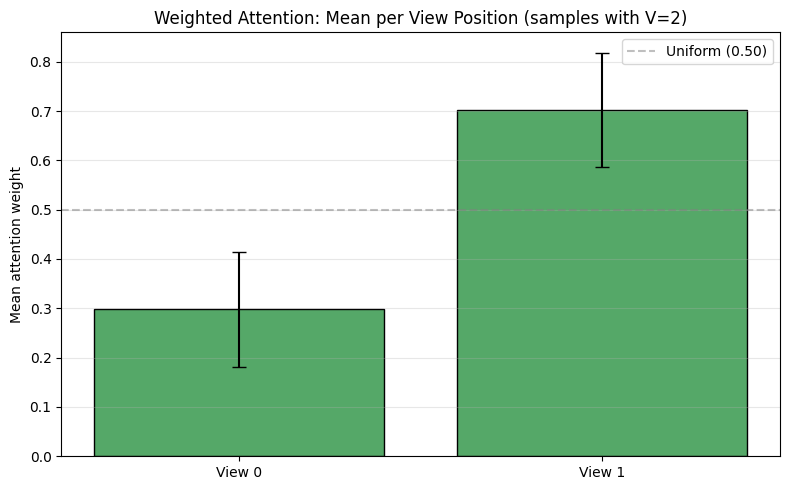

In [11]:
target_V = pd.Series(view_counts).value_counts().idxmax()
print(f'Analyzing samples with exactly V={target_V} views ({sum(1 for e in entries if e["num_views"] == target_V)} samples)')

attn_stack = np.array([
    np.array(e['attention'])[0] for e in entries if e['num_views'] == target_V
])  # (N, V)

mean_attn = attn_stack.mean(axis=0)
std_attn = attn_stack.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(target_V)

ax.bar(x, mean_attn, yerr=std_attn, capsize=5, color='#55A868', edgecolor='black')
ax.axhline(y=1/target_V, color='gray', linestyle='--', alpha=0.5, label=f'Uniform ({1/target_V:.2f})')
ax.set_xticks(x)
ax.set_xticklabels([f'View {i}' for i in range(target_V)])
ax.set_ylabel('Mean attention weight')
ax.set_title(f'Weighted Attention: Mean per View Position (samples with V={target_V})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/plot_weighted_attention_per_view.png', dpi=150)
plt.show()

### Sterke positionele bias richting View 1

Op samples met V=2 plaatst weighted attention gemiddeld 0.30 op View 0 en 0.70 op View 1. Dat is een grote en consistente afwijking van de uniform-lijn op 0.50. De foutbalken (ongeveer 0.12) laten zien dat er per sample variatie is, maar de richting van de bias is consistent: bijna elk sample weegt View 1 hoger. In de VARS dataset is view-indexering niet semantisch vastgelegd (View 0 is niet gegarandeerd een specifieke camera), maar in de annotatieconventie komt de main broadcast camera vaak eerst en staan replay- of close-up-camera's later. Het model lijkt geleerd te hebben dat latere views (meestal dichterbij of vertraagde replays) gemiddeld meer informatie bevatten.

## Per-klasse attention heatmap

Gemiddelde attention per view-positie, gegroepeerd op ground-truth actieklasse. Duidelijk verschillende rijen zouden klasse-specifieke view-selectie betekenen.

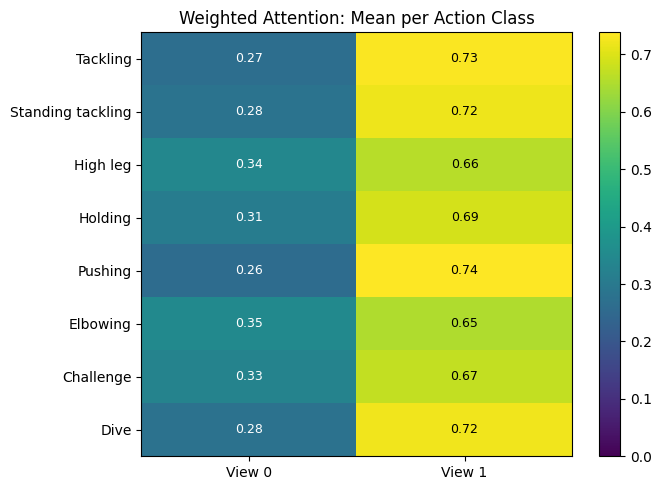

In [12]:
action_classes = ['Tackling', 'Standing tackling', 'High leg', 'Holding',
                  'Pushing', 'Elbowing', 'Challenge', 'Dive']

fig, ax = plt.subplots(figsize=(7, 5))
heatmap = np.zeros((len(action_classes), target_V))
for i, cls in enumerate(action_classes):
    cls_entries = [e for e in entries
                   if e['gt_action_class'] == cls and e['num_views'] == target_V]
    if not cls_entries:
        continue
    attns = np.array([np.array(e['attention'])[0] for e in cls_entries])
    heatmap[i] = attns.mean(axis=0)

im = ax.imshow(heatmap, cmap='viridis', aspect='auto', vmin=0, vmax=heatmap.max())
ax.set_xticks(range(target_V))
ax.set_xticklabels([f'View {i}' for i in range(target_V)])
ax.set_yticks(range(len(action_classes)))
ax.set_yticklabels(action_classes)
ax.set_title('Weighted Attention: Mean per Action Class')

for i in range(len(action_classes)):
    for j in range(target_V):
        txt_color = 'white' if heatmap[i, j] < heatmap.max() * 0.6 else 'black'
        ax.text(j, i, f'{heatmap[i, j]:.2f}', ha='center', va='center',
                color=txt_color, fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../plots/plot_weighted_attention_heatmap.png', dpi=150)
plt.show()

### De bias is positioneel, niet klasse-specifiek

Elke actieklasse laat hetzelfde patroon zien: View 0 tussen 0.26 en 0.35, View 1 tussen 0.65 en 0.74. De rijen van de heatmap zijn in feite identiek. Weighted attention heeft dus een enkele globale regel geleerd ("vertrouw View 1 meer") en past die toe ongeacht het type overtreding. Er is geen bewijs dat verschillende overtredingen voordeel halen uit verschillende camerahoeken. Het kleine bereik van de waarden per klasse (in totaal ongeveer 0.09 spreiding per kolom) is vergelijkbaar met samplingruis, dus de kleine verschillen tussen klassen moeten niet overdreven worden. Wat het model heeft geleerd is een vaste positionele prior, geen klasse-afhankelijke view-selectie.

## Conclusie

Weighted attention leert wel iets, maar wat hij leert is beperkt. De module is geconvergeerd naar een vaste positionele bias van ongeveer 30/70 ten gunste van View 1 boven View 0. Deze bias wordt uniform toegepast op elke actieklasse en past zich niet aan het type overtreding aan. De attention-verdeling is niet-uniform (gemiddelde entropie-ratio 0.854), maar de bron van die niet-uniformiteit is een globale "kies latere views" prior, geen sample-specifieke redenering.

Vergeleken met cross-attention, die instortte naar bijna-uniforme aandacht (entropie-ratio 0.988), heeft weighted attention tenminste een bruikbaar stukje informatie uit de views gehaald. Dit klopt met de kwantitatieve bevinding dat weighted attention de beste test leaderboard waarde haalt (35.3) onder de drie methoden. De informatie die hij heeft geleerd is echter simpel genoeg dat een goed geordende dataset hetzelfde in principe met een handgeschreven regel kan reproduceren. De ongeveer 262k parameters in `WeightedAggregate` komen neer op het leren dat de ene camerapositie gemiddeld informatiever is dan de andere.

Samen suggereren de cross-attention en weighted-attention analyses dat op SoccerNet-MVFoul op deze schaal het bruikbare signaal voor aggregatie oppervlakkig is. Een simpele positionele prior vangt het meeste van wat leerbaar is. Meer expressieve attention-modules reproduceren de positionele prior (weighted attention) of leren zelfs dat niet (cross-attention), met de extra parameters die als ruis fungeren. Multi-view aggregatie op deze dataset wordt niet beperkt door de expressiviteit van de module maar door de hoeveelheid signaal in de trainingsverdeling.